Başlangıç Q-Tablosu:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Durum Uzayı:
 16
Aksiyon Uzayı:
 4
Eğitim Tamamlandı.
Q-Tablosu:
 [[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.         0.        ]
 [0.5586617  0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.81450625 0.        ]
 [0.857375   0.76       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     

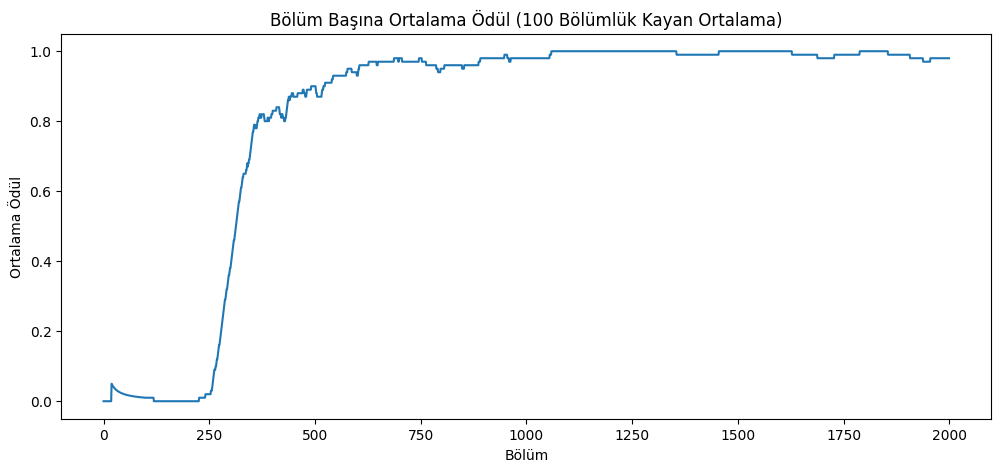

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

# --- Ortamı Oluşturma ---
# is_slippery=False ile ortamı deterministik yapıyoruz ki öğrenme sürecini daha net görelim.
env = gym.make('FrozenLake-v1', is_slippery=False)

# --- Q-Learning Hiperparametreleri ---
learning_rate = 0.8  # Alfa: Yeni bilgiye ne kadar önem vereceğimiz
gamma = 0.95         # Gama: Gelecekteki ödüllere ne kadar önem vereceğimiz
total_episodes = 2000

# Keşif (Exploration) parametreleri
epsilon = 1.0               # Başlangıçta tamamen rastgele başla
max_epsilon = 1.0           # Maksimum epsilon değeri
min_epsilon = 0.01          # Minimum epsilon değeri
decay_rate = 0.005          # Epsilon'un azalma oranı

# --- Q-Tablosunu Başlatma ---
# Durum sayısı x Eylem sayısı boyutunda, sıfırlarla dolu bir tablo oluşturuyoruz.
state_space_size = env.observation_space.n
action_space_size = env.action_space.n
q_table = np.zeros((state_space_size, action_space_size))
print("Başlangıç Q-Tablosu:\n", q_table)
print("Durum Uzayı:\n", state_space_size)
print("Aksiyon Uzayı:\n", action_space_size)

# Loglama için
rewards_per_episode = []
scores_deque = deque(maxlen=100)

# --- Eğitim Döngüsü ---
for episode in range(total_episodes):
    state, _ = env.reset()
    done = False
    total_rewards = 0
    
    for step in range(100): # Bir bölümün maksimum adım sayısı
        # 1. Epsilon-Greedy Eylem Seçimi
        if random.uniform(0, 1) > epsilon:
            # Sömürü (Exploitation): En iyi bilinen eylemi seç
            action = np.argmax(q_table[state, :])
        else:
            # Keşif (Exploration): Rastgele bir eylem seç
            action = env.action_space.sample()
            
        # 2. Eylemi Gerçekleştir ve Geri Bildirim Al
        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # 3. Bellman Optimalite Denklemi ile Q-Tablosunu Güncelle (Q-LEARNING'in Kalbi)
        q_table[state, action] = q_table[state, action] + learning_rate * (reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action])
        
        state = new_state
        total_rewards += reward
        
        if done:
            break
            
    # 4. Epsilon Değerini Güncelle (Keşfi zamanla azalt)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    
    scores_deque.append(total_rewards)
    rewards_per_episode.append(np.mean(scores_deque))

env.close()

# --- Sonuçları Görselleştirme ---
print("Eğitim Tamamlandı.")
print("Q-Tablosu:\n", q_table)

plt.figure(figsize=(12, 5))
plt.plot(rewards_per_episode)
plt.title('Bölüm Başına Ortalama Ödül (100 Bölümlük Kayan Ortalama)')
plt.xlabel('Bölüm')
plt.ylabel('Ortalama Ödül')
plt.show()
